In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt

from math import sqrt
from math import log

In [2]:
datasrc = pd.read_csv('../data/students_all_vle.csv')

In [3]:
datasrc.drop(columns=['id_student', 'code_module_x', 'region', 'date_unregistration', 'code_presentation', 'code_module_y'], inplace=True)

In [4]:
data_clean = datasrc.fillna(datasrc.mean(numeric_only=True)).dropna()

In [5]:
education_order = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}

data_clean['highest_education'] = datasrc['highest_education'].map(education_order)

In [6]:
imd_order = {
    '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4, '50-60%': 5,
    '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
data_clean['imd_band'] = datasrc['imd_band'].map(imd_order)

In [7]:
final_result_mapping = {
    'Distinction': 3,
    'Pass': 2,
    'Fail': 1,
    'Withdrawn': 0
    }

data_clean['final_result'] = datasrc['final_result'].map(final_result_mapping)

In [8]:
age_band_mapping = {
    '0-35': 1,
    '35-55': 2,
    '55<': 3
}
data_clean['age_band'] = datasrc['age_band'].map(age_band_mapping)

In [9]:
gender_mapping = {
    'M': 0,
    'F': 1
}
data_clean['gender'] = datasrc['gender'].map(gender_mapping)

In [10]:
disability_mapping = {
    'Y': 1,
    'N': 0
}
data_clean['disability'] = datasrc['disability'].map(disability_mapping)

In [11]:
numerical_columns = data_clean.select_dtypes(include=[np.number]).columns

In [12]:
data_clean.select_dtypes(exclude=[np.number]).columns

Index([], dtype='object')

In [13]:
le = LabelEncoder()
data_clean['gender'] = le.fit_transform(data_clean['gender'])
data_clean['disability'] = le.fit_transform(data_clean['disability'])

In [14]:
catigorical_columns = data_clean.select_dtypes(include=['object']).columns
for col in catigorical_columns:
    oh = OneHotEncoder(sparse_output=False, drop='first')
    data_clean_oh = oh.fit_transform(data_clean[[col]])
    cols = [f"{col}_{category}" for category in oh.categories_[0][1:]]
    df_oh = pd.DataFrame(data_clean_oh, columns=cols)
    data_clean = pd.concat([data_clean, df_oh], axis=1)
    data_clean.drop(columns=[col], inplace=True)

In [15]:
data_clean['studied_credits'] = [log(x) for x in data_clean['studied_credits']]

In [16]:
data_clean['avrage_assessment'] = [x**2 for x in data_clean['avrage_assessment']]

In [ ]:
click_metrics = data_clean.columns[data_clean.columns.str.contains('click')]

In [ ]:
data_clean[click_metrics] = data_clean[click_metrics].apply(lambda x: log(x))

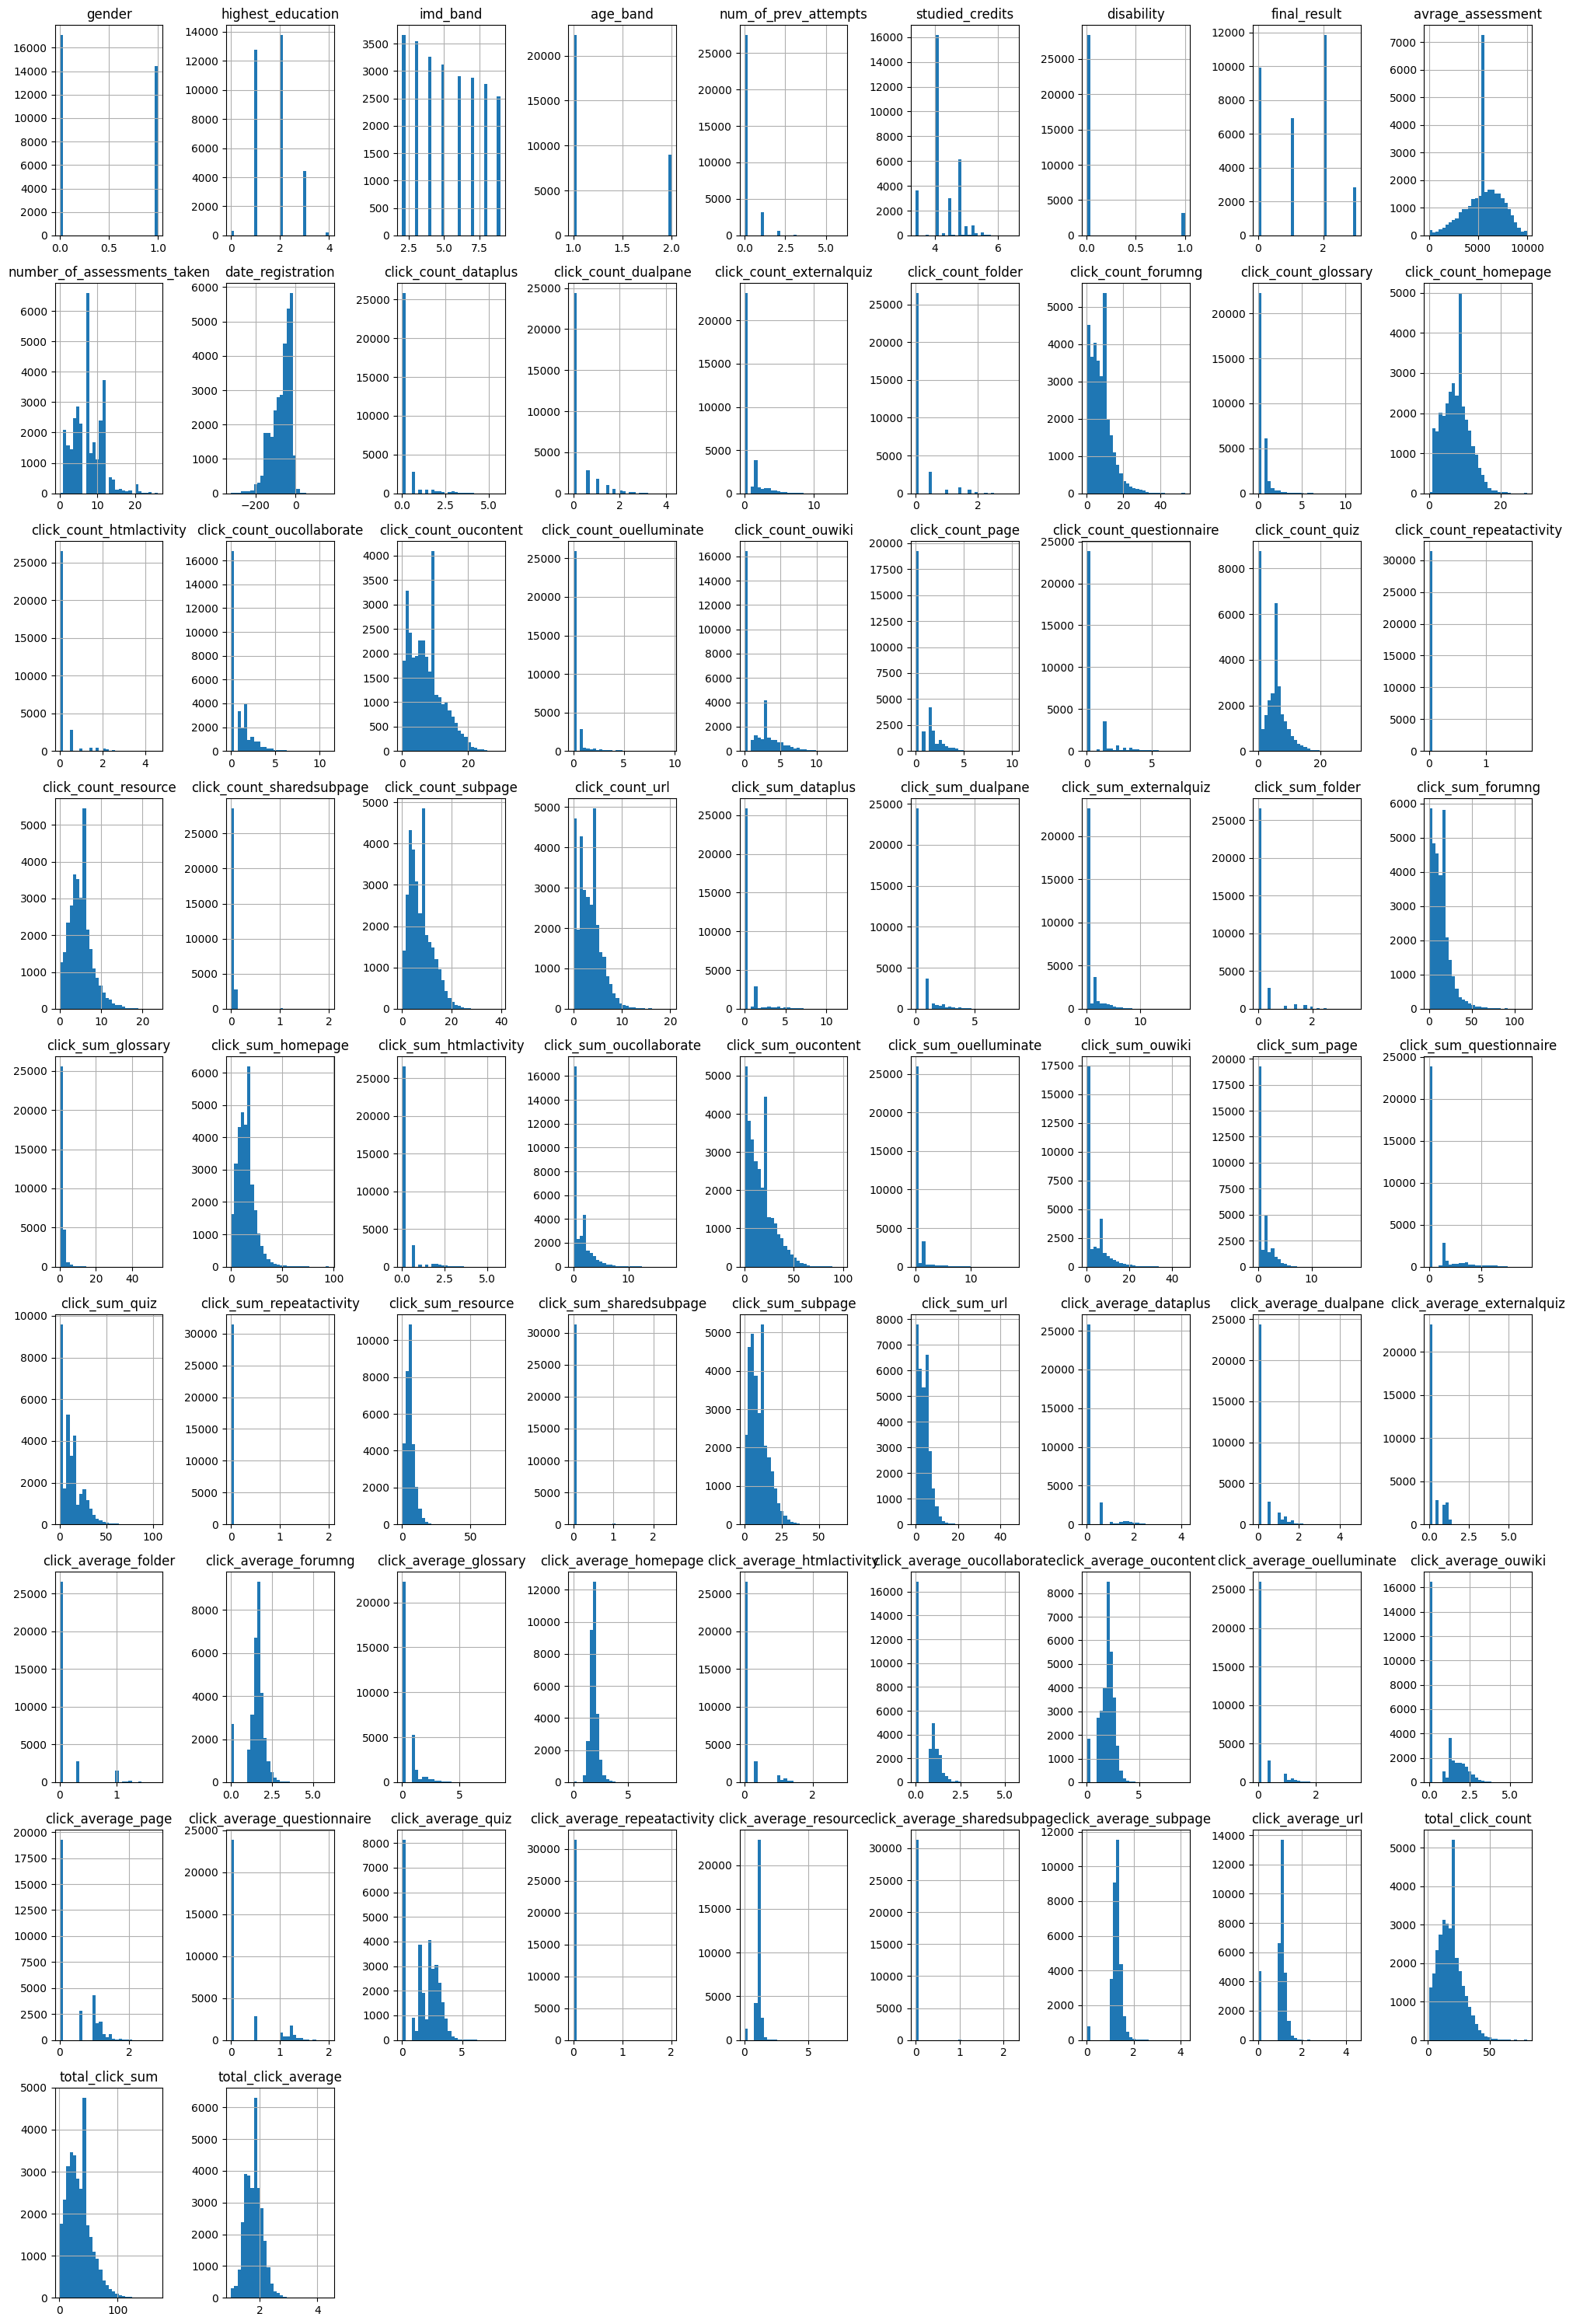

In [19]:
data_clean.hist(figsize=(20, 30), bins=30)
plt.tight_layout()
plt.show()

In [20]:
# data_clean[numerical_columns] = (data_clean[numerical_columns] - data_clean[numerical_columns].mean()) / data_clean[numerical_columns].std()

In [21]:
data_clean.head()

,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avrage_assessment,number_of_assessments_taken,...,click_average_questionnaire,click_average_quiz,click_average_repeatactivity,click_average_resource,click_average_sharedsubpage,click_average_subpage,click_average_url,total_click_count,total_click_sum,total_click_average
0,0,3,9.0,NaN,0,5.480639,0,2,6724.000000,5.000000,...,0.0,0.0,0.0,1.087115,0.0,1.705606,1.118034,14.000000,30.561414,2.182958
1,1,3,2.0,2.0,0,4.094345,0,2,4408.960000,5.000000,...,0.0,0.0,0.0,1.154701,0.0,1.439246,1.333333,20.736441,37.881394,1.826803
2,1,2,3.0,2.0,0,4.094345,1,0,5341.435533,7.494335,...,0.0,0.0,0.0,1.000000,0.0,1.354006,1.000000,8.717798,16.763055,1.922854
3,1,2,5.0,2.0,0,4.094345,0,2,5776.000000,5.000000,...,0.0,0.0,0.0,1.208941,0.0,1.317171,1.328422,25.748786,46.454279,1.804135
4,1,1,5.0,1.0,0,4.094345,0,2,2959.360000,5.000000,...,0.0,0.0,0.0,1.398757,0.0,1.220887,1.037749,18.761663,32.155870,1.713914


In [22]:
# data_clean.to_csv('../data/students_normalised_cleaned.csv', index=False)